# PINN-MPC v6 Alpha: Linear Guidance PID vs MPPI Quick v8 Checkpoint Auto Search

This notebook tests the controllers with an explicit, simple reference trajectory instead of a learned or shaped guidance profile.

Default experiment with checkpoint auto-search:

- initial altitude: 3000 ft
- target altitude: 5000 ft
- guidance: linear altitude ramp over `GUIDANCE_CLIMB_TIME_S`
- controllers: PID and MPPI-MPC only

The goal is to isolate the controller behavior: if a clean linear reference is given, can PID and PINN-MPC follow it through the JSBSim C172 plant?

The guidance interface is written so later S&C maneuver references can be plugged in, such as pitch doublet, pull-up, pushover, and pull-up/pull-over.


## 0. Install & Imports


In [1]:
!pip install jsbsim optuna -q
print('Install complete')


Install complete


In [2]:
import os, json, time, random, warnings, glob
warnings.filterwarnings('ignore')

import jsbsim
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import optuna

CKPT_FILENAME = 'pinn_dynamics_c172_2d_v6_alpha.pt'
COMPATIBLE_CKPT_FILENAMES = [
    'pinn_dynamics_c172_2d_v6_alpha.pt',
    'pinn_dynamics_c172_2d_v7_guidance_alpha.pt',
]
EXPERIMENT_FAMILY = 'PINN_MPC'
EXPERIMENT_NAME = 'v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search'
RUN_STAMP = time.strftime('%Y%m%d_%H%M%S')
COLAB_DRIVE_MOUNTED = False

try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB_DRIVE_MOUNTED = True
except Exception:
    COLAB_DRIVE_MOUNTED = False

# Current training notebook saves v6 alpha here. Older project paths are kept as
# fallbacks so old Drive layouts still work. If needed, override MODEL_PATH after
# this cell before running the checkpoint load cell.
MODEL_PATH_CANDIDATES = []
for _name in COMPATIBLE_CKPT_FILENAMES:
    MODEL_PATH_CANDIDATES += [
        f'/content/drive/MyDrive/PINN_MODEL_ONLY_v1/{_name}',
        f'/content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'/content/drive/MyDrive/PINN_MPC_Project/PINN_Model/{_name}',
        f'/content/drive/MyDrive/Colab Result/PINN_MPC/{_name}',
        f'/content/{_name}',
        f'./PINN_MODEL_ONLY_v1/{_name}',
        f'./PINN_MPC_Project/current best/PINN_Model/{_name}',
        f'./{_name}',
    ]

CHECKPOINT_SEARCH_ROOTS = [
    '/content/drive/MyDrive',
    '/content',
    '.',
]


def find_checkpoint_candidates():
    found = []
    for candidate in MODEL_PATH_CANDIDATES:
        if candidate and os.path.exists(candidate):
            found.append(candidate)

    patterns = []
    for root in CHECKPOINT_SEARCH_ROOTS:
        if os.path.exists(root):
            patterns.append(os.path.join(root, '**', 'pinn_dynamics_c172_2d*.pt'))
            patterns.append(os.path.join(root, '**', '*v6_alpha*.pt'))
            patterns.append(os.path.join(root, '**', '*v7_guidance_alpha*.pt'))

    for pattern in patterns:
        try:
            found.extend(glob.glob(pattern, recursive=True))
        except Exception as exc:
            print('Checkpoint search skipped pattern:', pattern, '|', repr(exc))

    # De-duplicate while preserving order, then prefer exact v6 alpha names.
    unique = []
    seen = set()
    for item in found:
        item = os.path.abspath(item)
        if item not in seen and os.path.exists(item):
            unique.append(item)
            seen.add(item)

    def rank(path):
        name = os.path.basename(path)
        if name == 'pinn_dynamics_c172_2d_v6_alpha.pt':
            return (0, -os.path.getmtime(path))
        if name == 'pinn_dynamics_c172_2d_v7_guidance_alpha.pt':
            return (1, -os.path.getmtime(path))
        return (2, -os.path.getmtime(path))

    return sorted(unique, key=rank)


def resolve_model_path():
    candidates = find_checkpoint_candidates()
    if candidates:
        return candidates[0]
    return MODEL_PATH_CANDIDATES[0]


MODEL_PATH = resolve_model_path()
FOUND_MODEL_PATHS = find_checkpoint_candidates()

# Result policy: code stays in the repository; generated outputs go to a
# separate Colab Result folder. Each run gets a timestamped archive directory.
RESULT_ROOT = '/content/drive/MyDrive/Colab Result' if COLAB_DRIVE_MOUNTED else './Colab Result'
RESULT_MODEL_DIR = os.path.join(RESULT_ROOT, EXPERIMENT_FAMILY, EXPERIMENT_NAME)
RESULT_ARCHIVE_DIR = os.path.join(RESULT_MODEL_DIR, 'archive')
RESULT_LATEST_DIR = os.path.join(RESULT_MODEL_DIR, 'latest')
SAVE_DIR = os.path.join(RESULT_ARCHIVE_DIR, RUN_STAMP)
for _path in [RESULT_ROOT, RESULT_MODEL_DIR, RESULT_ARCHIVE_DIR, RESULT_LATEST_DIR, SAVE_DIR]:
    os.makedirs(_path, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('COLAB_DRIVE_MOUNTED:', COLAB_DRIVE_MOUNTED)
print('MODEL_PATH:', MODEL_PATH)
print('MODEL_EXISTS:', os.path.exists(MODEL_PATH))
print('FOUND_MODEL_PATHS:')
for item in FOUND_MODEL_PATHS[:20]:
    print(' -', item)
if len(FOUND_MODEL_PATHS) > 20:
    print(f' ... {len(FOUND_MODEL_PATHS) - 20} more')
print('RESULT_ROOT:', RESULT_ROOT)
print('RESULT_MODEL_DIR:', RESULT_MODEL_DIR)
print('SAVE_DIR:', SAVE_DIR)
print('RESULT_LATEST_DIR:', RESULT_LATEST_DIR)
if not os.path.exists(MODEL_PATH):
    print('No compatible checkpoint was found. Put one of these files in Drive:')
    for name in COMPATIBLE_CKPT_FILENAMES:
        print(' - /content/drive/MyDrive/PINN_MODEL_ONLY_v1/' + name)
    print('Or set MODEL_PATH manually before running the checkpoint load cell.')

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Mounted at /content/drive
Device: cpu
COLAB_DRIVE_MOUNTED: True
MODEL_PATH: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
MODEL_EXISTS: True
FOUND_MODEL_PATHS:
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_2_warmstart.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v5_1_sequence.pt
 - /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/_Archive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d.pt
RESULT_ROOT: /content/drive/MyDrive/Colab Result
RESULT_MODEL_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search
SAVE_DIR: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_aut

## 1. Configuration


In [3]:
# Run modes:
# - "quick": cost sanity check + fast PID vs MPPI comparison
# - "debug": MPPI-only short debug run
# - "single": PID vs MPPI with a little more time
# - "full": longer PID, Random Shooting, CEM, MPPI comparison
RUN_MODE = 'quick'
DEBUG_STRICT_ASSERTS = False
NOTEBOOK_REVISION = 'v8_checkpoint_auto_search'

# PINN is loaded only. No PINN data collection or training is performed here.
PINN_LOAD_ONLY = True

# Keep this False while debugging the MPC cost. PID tuning is slow and is not
# needed to check whether the MPC cost is shaped correctly.
TUNE_PID_WITH_OPTUNA = False
DEFAULT_PID_PARAMS = {
    'kp_alt': 0.0015,
    'kp': 1.2,
    'ki': 0.02,
    'kd': 0.12,
    'kq': 0.35,
}

INIT_ALT = 3000.0
TARGET_ALT = 5000.0
THROTTLE = 0.85
DT = 0.02

STATE_COLS = ['h', 'V', 'theta', 'q', 'alpha']
INPUT_COLS = ['elevator', 'prev_elevator', 'delevator']
FEAT_COLS = STATE_COLS + INPUT_COLS
TGT_COLS = ['dh', 'dV', 'dtheta', 'dq', 'dalpha']

REACHED_BAND_FT = 100.0
REACHED_HOLD_STEPS = 60

PITCH_LIMIT_DEG = 25.0
PITCH_ABORT_DEG = 65.0
ALPHA_LIMIT_DEG = 18.0
ALT_MIN_FT = 500.0
ALT_MAX_FT = 12000.0

ELEV_LIMIT = 0.45
DELTA_ELEV_LIMIT = 0.08

# Recompute MPC only every N JSBSim steps. Quick mode uses 0.20 s updates.
CONTROL_INTERVAL = 10

# Explicit controller-test guidance. This is not PINN training guidance.
GUIDANCE_KIND = 'linear_altitude'
GUIDANCE_CLIMB_TIME_S = 60.0
GUIDANCE_LINEAR_START_ALT_FT = INIT_ALT
GUIDANCE_LINEAR_TARGET_ALT_FT = TARGET_ALT
GUIDANCE_TRIM_ALPHA_RAD = 0.035
GUIDANCE_AIRSPEED_FPS = 105.0
GUIDANCE_ALT_TRACK_SCALE_FT = 8.0
GUIDANCE_VS_SCALE_FPS = 5.0
GUIDANCE_Q_SCALE_RAD_S = 0.10
THETA_CMD_LIMIT = 0.24
THETA_TRACK_SCALE = 0.045
GLOBAL_ALT_SCALE_FT = 700.0
GUIDANCE_PROGRESS_SCALE_FT = 3.0

# MPPI is still stochastic, so a few deterministic anchor sequences are added
# to avoid missing the climb direction with very small sample counts.
MPPI_USE_ANCHOR_SEQUENCES = True
MPPI_ANCHOR_LEVELS = [-0.30, -0.15, 0.0, 0.15, 0.30]

if RUN_MODE == 'quick':
    MAX_STEPS = 900
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = 0
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'debug':
    MAX_STEPS = 500
    PID_TRIALS = 0
    MPC_HORIZON = 100
    MPC_SAMPLES = 16
    CEM_ITERS = 1
    N_TEST_CASES = 0
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['MPPI']
elif RUN_MODE == 'single':
    MAX_STEPS = 1600
    PID_TRIALS = 0
    MPC_HORIZON = 150
    MPC_SAMPLES = 24
    CEM_ITERS = 1
    N_TEST_CASES = 0
    CONTROL_INTERVAL = 10
    SELECTED_CONTROLLERS = ['PID', 'MPPI']
elif RUN_MODE == 'full':
    MAX_STEPS = 3000
    PID_TRIALS = 35
    MPC_HORIZON = 180
    MPC_SAMPLES = 48
    CEM_ITERS = 1
    N_TEST_CASES = 2
    SELECTED_CONTROLLERS = ['PID', 'Random', 'CEM', 'MPPI']
    TUNE_PID_WITH_OPTUNA = True
else:
    raise ValueError(f'Unknown RUN_MODE: {RUN_MODE}')

MPC_HORIZON_SECONDS = MPC_HORIZON * DT
CONTROL_INTERVAL_SECONDS = CONTROL_INTERVAL * DT
GUIDANCE_LINEAR_RATE_FPS = (GUIDANCE_LINEAR_TARGET_ALT_FT - GUIDANCE_LINEAR_START_ALT_FT) / max(GUIDANCE_CLIMB_TIME_S, 1e-6)

CONFIG = dict(
    RUN_MODE=RUN_MODE,
    DEBUG_STRICT_ASSERTS=DEBUG_STRICT_ASSERTS,
    NOTEBOOK_REVISION=NOTEBOOK_REVISION,
    EXPERIMENT_FAMILY=EXPERIMENT_FAMILY,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    RUN_STAMP=RUN_STAMP,
    RESULT_ROOT=RESULT_ROOT,
    RESULT_MODEL_DIR=RESULT_MODEL_DIR,
    RESULT_ARCHIVE_DIR=RESULT_ARCHIVE_DIR,
    RESULT_LATEST_DIR=RESULT_LATEST_DIR,
    SAVE_DIR=SAVE_DIR,
    PINN_LOAD_ONLY=PINN_LOAD_ONLY,
    TUNE_PID_WITH_OPTUNA=TUNE_PID_WITH_OPTUNA,
    INIT_ALT=INIT_ALT,
    TARGET_ALT=TARGET_ALT,
    THROTTLE=THROTTLE,
    DT=DT,
    MAX_STEPS=MAX_STEPS,
    PID_TRIALS=PID_TRIALS,
    MPC_HORIZON=MPC_HORIZON,
    MPC_HORIZON_SECONDS=MPC_HORIZON_SECONDS,
    MPC_SAMPLES=MPC_SAMPLES,
    CEM_ITERS=CEM_ITERS,
    N_TEST_CASES=N_TEST_CASES,
    CONTROL_INTERVAL=CONTROL_INTERVAL,
    CONTROL_INTERVAL_SECONDS=CONTROL_INTERVAL_SECONDS,
    SELECTED_CONTROLLERS=SELECTED_CONTROLLERS,
    ELEV_LIMIT=ELEV_LIMIT,
    DELTA_ELEV_LIMIT=DELTA_ELEV_LIMIT,
    GUIDANCE_KIND=GUIDANCE_KIND,
    GUIDANCE_CLIMB_TIME_S=GUIDANCE_CLIMB_TIME_S,
    GUIDANCE_LINEAR_START_ALT_FT=GUIDANCE_LINEAR_START_ALT_FT,
    GUIDANCE_LINEAR_TARGET_ALT_FT=GUIDANCE_LINEAR_TARGET_ALT_FT,
    GUIDANCE_LINEAR_RATE_FPS=GUIDANCE_LINEAR_RATE_FPS,
    GUIDANCE_TRIM_ALPHA_RAD=GUIDANCE_TRIM_ALPHA_RAD,
    GUIDANCE_AIRSPEED_FPS=GUIDANCE_AIRSPEED_FPS,
    GUIDANCE_ALT_TRACK_SCALE_FT=GUIDANCE_ALT_TRACK_SCALE_FT,
    GUIDANCE_VS_SCALE_FPS=GUIDANCE_VS_SCALE_FPS,
    GUIDANCE_Q_SCALE_RAD_S=GUIDANCE_Q_SCALE_RAD_S,
    THETA_CMD_LIMIT=THETA_CMD_LIMIT,
    THETA_TRACK_SCALE=THETA_TRACK_SCALE,
    GLOBAL_ALT_SCALE_FT=GLOBAL_ALT_SCALE_FT,
    GUIDANCE_PROGRESS_SCALE_FT=GUIDANCE_PROGRESS_SCALE_FT,
    MPPI_USE_ANCHOR_SEQUENCES=MPPI_USE_ANCHOR_SEQUENCES,
    MPPI_ANCHOR_LEVELS=MPPI_ANCHOR_LEVELS,
)
print(json.dumps(CONFIG, indent=2))


{
  "RUN_MODE": "quick",
  "DEBUG_STRICT_ASSERTS": false,
  "NOTEBOOK_REVISION": "v8_checkpoint_auto_search",
  "EXPERIMENT_FAMILY": "PINN_MPC",
  "EXPERIMENT_NAME": "v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search",
  "RUN_STAMP": "20260502_230334",
  "RESULT_ROOT": "/content/drive/MyDrive/Colab Result",
  "RESULT_MODEL_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search",
  "RESULT_ARCHIVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/archive",
  "RESULT_LATEST_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/latest",
  "SAVE_DIR": "/content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/archive/20260502_230334",
  "PINN_LOAD_ONLY": true,
  "TUNE_PID_WITH_OPTUNA": false,
  "INIT_ALT": 3000.0,
  "TARGET_ALT": 

## 2. JSBSim Plant Helpers


In [4]:
def get_prop(fdm, name, default=0.0):
    try:
        return float(fdm[name])
    except Exception:
        return float(default)


def make_fdm(init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0):
    fdm = jsbsim.FGFDMExec(None, None)
    fdm.set_debug_level(0)
    fdm.load_model('c172p')
    fdm['ic/h-sl-ft'] = float(init_alt)
    fdm['ic/vt-kts'] = float(init_speed)
    fdm['ic/theta-deg'] = float(init_pitch)
    fdm['ic/psi-true-deg'] = 0.0
    fdm.run_ic()
    fdm['propulsion/engine/set-running'] = 1
    fdm['fcs/throttle-cmd-norm'] = THROTTLE
    return fdm


def read_state(fdm):
    return np.array([
        get_prop(fdm, 'position/h-sl-ft'),
        get_prop(fdm, 'velocities/vt-fps'),
        get_prop(fdm, 'attitude/theta-rad'),
        get_prop(fdm, 'velocities/q-rad_sec'),
        get_prop(fdm, 'aero/alpha-rad', 0.0),
    ], dtype=np.float32)


def apply_control(fdm, elevator):
    fdm['fcs/elevator-cmd-norm'] = float(np.clip(elevator, -1.0, 1.0))
    fdm.run()


print('JSBSim helpers ready')


JSBSim helpers ready


## 3. Load Saved v6 Alpha PINN Checkpoint

This section reconstructs the network architecture and loads `model_state` from disk. It does not train, fit, optimize, or update the PINN parameters.


In [5]:
class PhysicsPINN(nn.Module):
    def __init__(self, hidden_dim=192, n_layers=4, stats=None):
        super().__init__()
        input_dim = len(FEAT_COLS)
        output_dim = len(TGT_COLS)
        self.register_buffer('Xm', stats['Xm'].clone() if stats else torch.zeros(input_dim))
        self.register_buffer('Xs', stats['Xs'].clone() if stats else torch.ones(input_dim))
        self.register_buffer('Ym', stats['Ym'].clone() if stats else torch.zeros(output_dim))
        self.register_buffer('Ys', stats['Ys'].clone() if stats else torch.ones(output_dim))

        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x_norm):
        return self.net(x_norm)

    def denorm_delta(self, d_norm, add_mean=True):
        if add_mean:
            return d_norm * self.Ys + self.Ym
        return d_norm * self.Ys


def _torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_pinn_checkpoint(path):
    candidates = []
    if path and os.path.exists(path):
        candidates.append(path)
    candidates.extend([p for p in FOUND_MODEL_PATHS if p not in candidates])

    load_errors = []
    for candidate in candidates:
        try:
            ckpt = _torch_load_checkpoint(candidate)
            missing = [k for k in ['model_state', 'stats', 'best_params'] if k not in ckpt]
            if missing:
                load_errors.append(f'{candidate}: missing keys {missing}')
                continue
            ckpt_features = list(ckpt.get('feature_cols', FEAT_COLS))
            ckpt_targets = list(ckpt.get('target_cols', TGT_COLS))
            if ckpt_features != FEAT_COLS or ckpt_targets != TGT_COLS:
                load_errors.append(
                    f'{candidate}: contract mismatch features={ckpt_features}, targets={ckpt_targets}'
                )
                continue
            return ckpt, candidate
        except Exception as exc:
            load_errors.append(f'{candidate}: {type(exc).__name__}: {exc}')

    message = [
        'Missing compatible trained PINN checkpoint.',
        f'Initial MODEL_PATH: {path}',
        'Expected feature contract:', str(FEAT_COLS),
        'Expected target contract:', str(TGT_COLS),
        'Searched/found candidates:',
    ]
    message += [f' - {p}' for p in (FOUND_MODEL_PATHS or MODEL_PATH_CANDIDATES[:10])]
    if load_errors:
        message += ['Load attempts:'] + [f' - {err}' for err in load_errors]
    message += [
        'Fix: run the v6 training notebook first, or copy a compatible checkpoint to:',
        '/content/drive/MyDrive/PINN_MODEL_ONLY_v1/pinn_dynamics_c172_2d_v6_alpha.pt',
        'You can also set MODEL_PATH manually before this cell.',
    ]
    raise FileNotFoundError('\n'.join(message))


assert PINN_LOAD_ONLY is True
checkpoint, MODEL_PATH = load_pinn_checkpoint(MODEL_PATH)

stats = {k: v.to(device) for k, v in checkpoint['stats'].items()}
params = checkpoint['best_params']

model = PhysicsPINN(
    hidden_dim=params.get('hidden_dim', 192),
    n_layers=params.get('n_layers', 4),
    stats=stats,
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ckpt_feature_cols = checkpoint.get('feature_cols', FEAT_COLS)
ckpt_target_cols = checkpoint.get('target_cols', TGT_COLS)

print('Loaded compatible PINN checkpoint:', MODEL_PATH)
print('PINN parameters frozen:', not any(p.requires_grad for p in model.parameters()))
print('best_params:', params)
print('feature_cols:', ckpt_feature_cols)
print('target_cols:', ckpt_target_cols)
print('auto_summary:', json.dumps(checkpoint.get('auto_summary', {}), indent=2))


Loaded compatible PINN checkpoint: /content/drive/MyDrive/Colab Notebooks/PINN_MPC_Project/current best/PINN_Model/pinn_dynamics_c172_2d_v6_alpha.pt
PINN parameters frozen: True
best_params: {'hidden_dim': 192, 'n_layers': 4, 'lr': 0.0005, 'lam_physics': 0.1, 'lam_smooth': 0.0005, 'lam_rollout': 0.1, 'target_weights': [1.0, 1.0, 2.0, 8.0, 2.0], 'epochs': 340}
feature_cols: ['h', 'V', 'theta', 'q', 'alpha', 'elevator', 'prev_elevator', 'delevator']
target_cols: ['dh', 'dV', 'dtheta', 'dq', 'dalpha']
auto_summary: {
  "best_cycle": 0,
  "best_rollout_score_val": 0.3200063483543797,
  "best_h_rmse_mean_val": 0.37132277619093657,
  "best_theta_rmse_mean_val": 0.0007993993785930797,
  "best_q_rmse_mean_val": 0.0018216835087514482,
  "final_rollout_score_test": 0.1880706141043144,
  "final_h_rmse_mean_test": 0.21852892497554421,
  "final_theta_rmse_mean_test": 0.0006437486226786859,
  "final_q_rmse_mean_test": 0.0007485623646061867,
  "test_targets_met": true,
  "auto_cycles_run": 0,
  "auto

## 4. PINN Rollout for Control


In [6]:
@torch.no_grad()
def pinn_step(model, state, elevator, prev_elevator):
    elevator = float(np.clip(elevator, -ELEV_LIMIT, ELEV_LIMIT))
    prev_elevator = float(np.clip(prev_elevator, -ELEV_LIMIT, ELEV_LIMIT))
    delevator = elevator - prev_elevator
    x = np.array([state[0], state[1], state[2], state[3], state[4],
                  elevator, prev_elevator, delevator], dtype=np.float32)
    xt = torch.tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
    xn = (xt - model.Xm) / model.Xs
    dn = model(xn)
    delta = model.denorm_delta(dn, add_mean=True).cpu().numpy()[0]
    return state + delta


@torch.no_grad()
def rollout_pinn_control(model, init_state, elevator_seq, prev_elevator):
    states = [np.asarray(init_state, dtype=np.float32).copy()]
    current = states[0].copy()
    prev = float(prev_elevator)
    applied = []
    for raw_elev in elevator_seq:
        elev = float(np.clip(raw_elev, prev - DELTA_ELEV_LIMIT, prev + DELTA_ELEV_LIMIT))
        elev = float(np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT))
        current = pinn_step(model, current, elev, prev)
        states.append(current.copy())
        applied.append(elev)
        prev = elev
    return np.asarray(states), np.asarray(applied, dtype=np.float32)


print('PINN control rollout ready')


PINN control rollout ready


## 5. PID Baseline Tuning


In [7]:
class TunedPID:
    def __init__(self, params):
        self.kp_alt = params['kp_alt']
        self.kp = params['kp']
        self.ki = params['ki']
        self.kd = params['kd']
        self.kq = params.get('kq', 0.0)
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0
        self.ILIM = 8.0

    def reset(self):
        self.integral = 0.0
        self.prev_err = 0.0
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        h, V, theta, q, alpha = state
        theta_cmd = guidance_first_theta(state, target_alt)
        err = theta_cmd - theta
        self.integral = np.clip(self.integral + err * DT, -self.ILIM, self.ILIM)
        deriv = (err - self.prev_err) / DT
        self.prev_err = err

        raw = self.kp * err + self.ki * self.integral + self.kd * deriv - self.kq * q
        elev = np.clip(raw, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT)
        elev = np.clip(elev, -ELEV_LIMIT, ELEV_LIMIT)
        self.prev_elev = float(elev)
        return float(elev), {'theta_cmd': float(theta_cmd), 'cost': abs(target_alt - h)}


def eval_pid_params(params, init_alt=INIT_ALT, target_alt=TARGET_ALT, n_steps=1400):
    controller = TunedPID(params)
    fdm = make_fdm(init_alt=init_alt)
    alts, pitches, qs, alphas, elevs = [], [], [], [], []

    for _ in range(n_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state
        if h < ALT_MIN_FT or h > ALT_MAX_FT or abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            return 1e8
        elev, _ = controller.update(state, target_alt)
        apply_control(fdm, elev)
        alts.append(h)
        pitches.append(np.degrees(theta))
        qs.append(np.degrees(q))
        alphas.append(np.degrees(alpha))
        elevs.append(elev)

    alts = np.asarray(alts)
    pitches = np.asarray(pitches)
    qs = np.asarray(qs)
    alphas = np.asarray(alphas)
    elevs = np.asarray(elevs)

    err = alts - target_alt
    tail = err[int(0.75 * len(err)):]
    rmse = np.sqrt(np.mean(err ** 2))
    tail_mae = np.mean(np.abs(tail))
    final_abs = abs(err[-1])
    reached = np.any(np.abs(err) <= REACHED_BAND_FT)

    pitch_pen = 10.0 * np.mean(np.maximum(0.0, np.abs(pitches) - PITCH_LIMIT_DEG) ** 2)
    alpha_pen = 6.0 * np.mean(np.maximum(0.0, np.abs(alphas) - ALPHA_LIMIT_DEG) ** 2)
    q_pen = 0.04 * np.mean(qs ** 2)
    effort = 15.0 * np.mean(np.diff(elevs, prepend=elevs[0]) ** 2)
    reach_pen = 450.0 if not reached else 0.0

    # The previous objective mostly optimized average RMSE. This version also
    # cares about final/tail error so Optuna does not choose an under-aggressive
    # altitude loop that looks smooth but never reaches the target.
    return float(0.40 * rmse + 0.45 * tail_mae + 0.25 * final_abs
                 + reach_pen + pitch_pen + alpha_pen + q_pen + effort)


def pid_objective(trial):
    params = {
        'kp_alt': trial.suggest_float('kp_alt', 0.00025, 0.0040, log=True),
        'kp': trial.suggest_float('kp', 0.10, 4.0, log=True),
        'ki': trial.suggest_float('ki', 0.0005, 0.20, log=True),
        'kd': trial.suggest_float('kd', 0.005, 2.0, log=True),
        'kq': trial.suggest_float('kq', 0.0, 2.0),
    }
    return eval_pid_params(params)


if TUNE_PID_WITH_OPTUNA:
    print(f'Tuning PID gains with {PID_TRIALS} Optuna trials. This does not retrain the PINN.')
    pid_study = optuna.create_study(direction='minimize')
    pid_study.optimize(pid_objective, n_trials=PID_TRIALS, show_progress_bar=True)
    PID_PARAMS = pid_study.best_params
    print('Best PID params:', PID_PARAMS)
    print('Best PID objective:', pid_study.best_value)
else:
    PID_PARAMS = dict(DEFAULT_PID_PARAMS)
    print('Using DEFAULT_PID_PARAMS:', PID_PARAMS)


Using DEFAULT_PID_PARAMS: {'kp_alt': 0.0015, 'kp': 1.2, 'ki': 0.02, 'kd': 0.12, 'kq': 0.35}


## 6. MPC Cost Function


In [8]:
def _as_state_vector(current_state):
    arr = np.asarray(current_state, dtype=np.float32)
    if arr.ndim == 0 or arr.size == 1:
        return np.array([float(arr), GUIDANCE_AIRSPEED_FPS, 0.0, 0.0, GUIDANCE_TRIM_ALPHA_RAD], dtype=np.float32)
    if arr.size < 5:
        raise ValueError('Guidance requires state [h, V, theta, q, alpha] or a scalar altitude fallback.')
    return arr[:5].astype(np.float32)


def make_linear_altitude_guidance(current_state, target_alt, horizon, dt):
    state = _as_state_vector(current_state)
    h0, V0, theta0, q0, alpha0 = [float(v) for v in state]
    horizon = int(horizon)
    if horizon <= 0:
        raise ValueError('horizon must be positive')

    t = np.arange(horizon, dtype=np.float32) * float(dt)
    rate = float(np.clip(
        GUIDANCE_LINEAR_RATE_FPS,
        -abs(GUIDANCE_LINEAR_RATE_FPS),
        abs(GUIDANCE_LINEAR_RATE_FPS),
    ))

    # Receding linear reference: from the current altitude, continue along the
    # same planned 3000->5000 ft slope. This keeps the reference visible inside
    # a short MPC horizon and is ideal for controller-only testing.
    h_ref = h0 + rate * t
    low = min(h0, target_alt)
    high = max(h0, target_alt)
    h_ref = np.clip(h_ref, low, high).astype(np.float32)

    vz_ref = np.ones(horizon, dtype=np.float32) * rate
    if (target_alt - h0) * rate <= 0.0:
        vz_ref[:] = 0.0

    speed_ref = np.ones(horizon, dtype=np.float32) * max(float(V0), 55.0)
    alpha_ref = np.ones(horizon, dtype=np.float32) * np.clip(
        GUIDANCE_TRIM_ALPHA_RAD if abs(alpha0) < 0.20 else alpha0,
        -0.12, 0.16,
    )
    gamma_ref = np.arcsin(np.clip(vz_ref / np.maximum(speed_ref, 1.0), -0.35, 0.35))
    theta_ref = np.clip(gamma_ref + alpha_ref, -THETA_CMD_LIMIT, THETA_CMD_LIMIT).astype(np.float32)
    q_ref = np.gradient(theta_ref, dt).astype(np.float32)

    return {
        'h_ref': h_ref,
        'vz_ref': vz_ref.astype(np.float32),
        'V_ref': speed_ref.astype(np.float32),
        'theta_ref': theta_ref,
        'q_ref': q_ref,
        'alpha_ref': alpha_ref,
        'target_alt': float(target_alt),
        'desired_vs': float(rate),
        'initial_error': float(target_alt - h0),
        'profile': GUIDANCE_KIND,
    }


def make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver='linear_altitude'):
    # Extension point for later S&C tests. Keep the return contract identical:
    # h_ref, vz_ref, V_ref, theta_ref, q_ref, alpha_ref.
    if maneuver == 'linear_altitude':
        return make_linear_altitude_guidance(current_state, target_alt, horizon, dt)
    raise NotImplementedError(f'Maneuver guidance not implemented yet: {maneuver}')


def make_mpc_altitude_guidance(current_state, target_alt, horizon, dt):
    return make_maneuver_guidance(current_state, target_alt, horizon, dt, maneuver=GUIDANCE_KIND)


def make_altitude_guidance(current_state, target_alt, horizon, dt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, horizon, dt)
    return guide['h_ref'], guide['vz_ref'], guide['theta_ref']


def guidance_first_theta(current_state, target_alt):
    guide = make_mpc_altitude_guidance(current_state, target_alt, 2, DT)
    return float(guide['theta_ref'][1] if len(guide['theta_ref']) > 1 else guide['theta_ref'][0])


def mpc_cost_components(predicted, target_alt, elev_seq):
    h = predicted[:, 0]
    V = predicted[:, 1]
    theta = predicted[:, 2]
    q = predicted[:, 3]
    alpha = predicted[:, 4]
    elev_seq = np.asarray(elev_seq, dtype=np.float32)

    guide = make_mpc_altitude_guidance(predicted[0], target_alt, len(h), DT)
    h_ref = guide['h_ref']
    vz_ref = guide['vz_ref']
    theta_ref = guide['theta_ref']
    q_ref = guide['q_ref']
    alpha_ref = guide['alpha_ref']

    dhdt = np.diff(h, prepend=h[0]) / DT
    initial_abs_err = abs(float(target_alt - h[0]))
    final_abs_err = abs(float(target_alt - h[-1]))
    expected_progress = min(initial_abs_err, abs(guide['desired_vs']) * (len(h) - 1) * DT)
    actual_progress = initial_abs_err - final_abs_err
    missing_progress = max(0.0, expected_progress - actual_progress)

    theta_deg = np.degrees(theta)
    q_deg = np.degrees(q)
    alpha_deg = np.degrees(alpha)

    components = {
        'guidance_alt': 4.00 * np.mean(((h - h_ref) / GUIDANCE_ALT_TRACK_SCALE_FT) ** 2),
        'guidance_vz': 2.00 * np.mean(((dhdt - vz_ref) / GUIDANCE_VS_SCALE_FPS) ** 2),
        'theta_track': 1.20 * np.mean(((theta - theta_ref) / THETA_TRACK_SCALE) ** 2),
        'q_track': 0.05 * np.mean(((q - q_ref) / GUIDANCE_Q_SCALE_RAD_S) ** 2),
        'alpha_track': 0.03 * np.mean(((alpha - alpha_ref) / max(np.deg2rad(8.0), 1e-6)) ** 2),
        'local_terminal': 2.00 * ((h[-1] - h_ref[-1]) / GUIDANCE_ALT_TRACK_SCALE_FT) ** 2,
        'global_terminal': 0.12 * ((h[-1] - target_alt) / GLOBAL_ALT_SCALE_FT) ** 2,
        'missing_progress': 3.00 * (missing_progress / GUIDANCE_PROGRESS_SCALE_FT) ** 2,
        'pitch_small': 0.0004 * np.mean(theta_deg ** 2),
        'pitch_limit': 30.0 * np.mean(np.maximum(0.0, np.abs(theta_deg) - PITCH_LIMIT_DEG) ** 2),
        'alpha_limit': 20.0 * np.mean(np.maximum(0.0, np.abs(alpha_deg) - ALPHA_LIMIT_DEG) ** 2),
        'q_penalty': 0.006 * np.mean(q_deg ** 2),
        'speed_floor': 0.0004 * np.mean(np.maximum(0.0, 55.0 - V) ** 2),
        'effort': 0.003 * np.mean(elev_seq ** 2) if len(elev_seq) else 0.0,
        'smooth': 0.020 * np.mean(np.diff(elev_seq, prepend=elev_seq[0]) ** 2) if len(elev_seq) else 0.0,
    }

    unsafe = np.any((h < ALT_MIN_FT) | (h > ALT_MAX_FT) | (np.abs(theta_deg) > PITCH_ABORT_DEG))
    components['abort'] = 1e3 if unsafe else 0.0
    components = {k: float(v) for k, v in components.items()}
    components['total'] = float(sum(components.values()))
    return components, guide


def mpc_cost(predicted, target_alt, elev_seq):
    components, _ = mpc_cost_components(predicted, target_alt, elev_seq)
    return components['total']


## 7. PINN-MPC Controllers


In [9]:
class RandomShootingMPC:
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.20):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def sample_sequences(self):
        noise = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        return np.clip(self.U[None, :] + noise, -ELEV_LIMIT, ELEV_LIMIT)

    def update(self, state, target_alt):
        seqs = self.sample_sequences()
        costs = np.empty(self.n_samples)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        action = float(best_applied[0])
        self.prev_elev = action
        self.U = np.append(best_applied[1:], best_applied[-1]).astype(np.float32)
        return action, {'cost': float(costs[best_idx]), 'best_cost': float(costs[best_idx])}


class CEMMPC:
    """
    Cross-Entropy Method MPC.

    CEM samples candidate control sequences around a nominal mean sequence,
    keeps only the elite low-cost samples, then updates the mean and standard
    deviation from those elites.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES,
                 elite_frac=0.15, init_sigma=0.22, min_sigma=0.04,
                 momentum=0.20, n_iters=CEM_ITERS):
        self.horizon = horizon
        self.n_samples = n_samples
        self.elite_frac = elite_frac
        self.init_sigma = init_sigma
        self.min_sigma = min_sigma
        self.momentum = momentum
        self.n_iters = n_iters
        self.U = np.zeros(horizon, dtype=np.float32)
        self.S = np.ones(horizon, dtype=np.float32) * init_sigma
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.S[:] = self.init_sigma
        self.prev_elev = 0.0

    def update(self, state, target_alt):
        mean = self.U.copy()
        std = self.S.copy()
        best_cost = np.inf
        best_applied = None

        for _ in range(self.n_iters):
            raw = np.random.normal(mean[None, :], std[None, :],
                                   size=(self.n_samples, self.horizon))
            seqs = np.clip(raw, -ELEV_LIMIT, ELEV_LIMIT)

            costs = np.empty(self.n_samples)
            applied_cache = []
            for i, seq in enumerate(seqs):
                pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
                costs[i] = mpc_cost(pred, target_alt, applied)
                applied_cache.append(applied)

            elite_n = max(2, int(self.elite_frac * self.n_samples))
            elite_idx = np.argsort(costs)[:elite_n]
            elite = np.asarray([applied_cache[i] for i in elite_idx])

            elite_mean = elite.mean(axis=0)
            elite_std = elite.std(axis=0) + 1e-6
            mean = self.momentum * mean + (1.0 - self.momentum) * elite_mean
            std = self.momentum * std + (1.0 - self.momentum) * elite_std
            std = np.clip(std, self.min_sigma, self.init_sigma)

            if costs[elite_idx[0]] < best_cost:
                best_cost = float(costs[elite_idx[0]])
                best_applied = applied_cache[int(elite_idx[0])]

        self.U = np.clip(mean, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        self.S = std.astype(np.float32)

        action = float(best_applied[0] if best_applied is not None else self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action

        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        self.S = np.append(self.S[1:], self.S[-1]).astype(np.float32)
        return action, {'cost': best_cost, 'best_cost': best_cost}


class MPPIMPC:
    """
    Model Predictive Path Integral MPC.

    MPPI uses all samples with soft exponential weights. Compared with CEM,
    this often gives smoother updates because there is no hard top-k cutoff.
    """
    def __init__(self, horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.22, lam=0.12):
        self.horizon = horizon
        self.n_samples = n_samples
        self.sigma = sigma
        self.lam = lam
        self.U = np.zeros(horizon, dtype=np.float32)
        self.prev_elev = 0.0

    def reset(self):
        self.U[:] = 0.0
        self.prev_elev = 0.0

    def anchor_sequences(self):
        anchors = []
        if MPPI_USE_ANCHOR_SEQUENCES:
            for level in MPPI_ANCHOR_LEVELS:
                anchors.append(np.ones(self.horizon, dtype=np.float32) * float(level))
            anchors.append(np.linspace(0.0, 0.30, self.horizon, dtype=np.float32))
            anchors.append(np.linspace(0.0, -0.30, self.horizon, dtype=np.float32))
        return anchors

    def update(self, state, target_alt):
        eps = np.random.normal(0.0, self.sigma, size=(self.n_samples, self.horizon))
        seqs = np.clip(self.U[None, :] + eps, -ELEV_LIMIT, ELEV_LIMIT)
        anchors = self.anchor_sequences()
        if anchors:
            seqs = np.vstack([seqs, np.asarray(anchors, dtype=np.float32)])

        costs = np.empty(len(seqs), dtype=np.float32)
        applied_cache = []
        for i, seq in enumerate(seqs):
            pred, applied = rollout_pinn_control(model, state, seq, self.prev_elev)
            costs[i] = mpc_cost(pred, target_alt, applied)
            applied_cache.append(applied)

        beta = costs.min()
        weights = np.exp(-(costs - beta) / max(self.lam, 1e-6))
        weights = weights / (weights.sum() + 1e-9)

        weighted_seq = np.sum(weights[:, None] * np.asarray(applied_cache), axis=0)
        self.U = np.clip(weighted_seq, -ELEV_LIMIT, ELEV_LIMIT).astype(np.float32)
        action = float(self.U[0])
        action = float(np.clip(action, self.prev_elev - DELTA_ELEV_LIMIT, self.prev_elev + DELTA_ELEV_LIMIT))
        action = float(np.clip(action, -ELEV_LIMIT, ELEV_LIMIT))
        self.prev_elev = action
        self.U = np.append(self.U[1:], self.U[-1]).astype(np.float32)
        best_idx = int(np.argmin(costs))
        best_applied = applied_cache[best_idx]
        return action, {
            'cost': float(np.sum(weights * costs)),
            'best_cost': float(beta),
            'best_first_elevator': float(best_applied[0]),
            'weighted_first_elevator': float(action),
        }


print('MPC controllers ready')
print('  RandomShootingMPC: simple sampling baseline')
print('  CEMMPC           : elite-sample sampling MPC')
print('  MPPIMPC          : soft-weighted sampling MPC')
print(f'  Horizon          : {MPC_HORIZON} steps = {MPC_HORIZON_SECONDS:.2f} seconds')


MPC controllers ready
  RandomShootingMPC: simple sampling baseline
  CEMMPC           : elite-sample sampling MPC
  MPPIMPC          : soft-weighted sampling MPC
  Horizon          : 100 steps = 2.00 seconds


## 8. Simulation Runner


In [10]:
def run_sim(controller, name, init_alt=INIT_ALT, init_speed=100.0, init_pitch=0.0,
            target_alt=TARGET_ALT, max_steps=None, control_interval=CONTROL_INTERVAL):
    fdm = make_fdm(init_alt=init_alt, init_speed=init_speed, init_pitch=init_pitch)
    controller.reset()
    hold_count = 0
    abort_reason = None
    max_steps = MAX_STEPS if max_steps is None else int(max_steps)

    last_elev = 0.0
    last_info = {'theta_cmd': np.nan, 'cost': np.nan}
    last_comp_ms = 0.0

    log = {k: [] for k in [
        'time', 'altitude', 'velocity', 'pitch_deg', 'pitch_rate_deg_s',
        'alpha_deg', 'elevator', 'theta_cmd_deg', 'cost', 'comp_ms', 'mpc_update'
    ]}

    for step in range(max_steps):
        state = read_state(fdm)
        h, V, theta, q, alpha = state

        if h < ALT_MIN_FT:
            abort_reason = f'LOW_ALT {h:.1f} ft'
            break
        if h > ALT_MAX_FT:
            abort_reason = f'HIGH_ALT {h:.1f} ft'
            break
        if abs(np.degrees(theta)) > PITCH_ABORT_DEG:
            abort_reason = f'PITCH_ABORT {np.degrees(theta):.1f} deg'
            break

        do_update = (step % control_interval == 0)
        if do_update:
            t0 = time.perf_counter()
            last_elev, last_info = controller.update(state, target_alt)
            last_comp_ms = (time.perf_counter() - t0) * 1000.0

        apply_control(fdm, last_elev)

        log['time'].append(step * DT)
        log['altitude'].append(float(h))
        log['velocity'].append(float(V))
        log['pitch_deg'].append(float(np.degrees(theta)))
        log['pitch_rate_deg_s'].append(float(np.degrees(q)))
        log['alpha_deg'].append(float(np.degrees(alpha)))
        log['elevator'].append(float(last_elev))
        log['theta_cmd_deg'].append(float(np.degrees(last_info.get('theta_cmd', np.nan))))
        log['cost'].append(float(last_info.get('cost', np.nan)))
        log['comp_ms'].append(float(last_comp_ms if do_update else 0.0))
        log['mpc_update'].append(bool(do_update))

        if abs(h - target_alt) < REACHED_BAND_FT:
            hold_count += 1
            if hold_count >= REACHED_HOLD_STEPS:
                break
        else:
            hold_count = 0

    log['name'] = name
    log['abort_reason'] = abort_reason
    log['init_alt'] = init_alt
    log['init_speed'] = init_speed
    log['init_pitch'] = init_pitch
    log['target_alt'] = target_alt
    log['control_interval'] = control_interval
    return log


def compute_metrics(log):
    alt = np.asarray(log['altitude'])
    pitch = np.asarray(log['pitch_deg'])
    q = np.asarray(log['pitch_rate_deg_s'])
    alpha = np.asarray(log['alpha_deg'])
    elev = np.asarray(log['elevator'])
    comp = np.asarray(log['comp_ms'])
    updates = np.asarray(log.get('mpc_update', np.ones_like(comp, dtype=bool)))
    t = np.asarray(log['time'])
    target = log['target_alt']

    if len(alt) == 0:
        return {'Controller': log['name'], 'Abort': log['abort_reason'] or 'EMPTY'}

    reached = np.where(np.abs(alt - target) < REACHED_BAND_FT)[0]
    reach_time = float(t[reached[0]]) if len(reached) else np.nan
    tail = max(1, int(0.2 * len(alt)))
    update_comp = comp[updates] if np.any(updates) else comp

    return {
        'Controller': log['name'],
        'Init Alt': round(log['init_alt'], 1),
        'Target Alt': round(target, 1),
        'Reach Time (s)': round(reach_time, 2) if np.isfinite(reach_time) else np.nan,
        'Alt RMSE (ft)': round(float(np.sqrt(np.mean((alt - target) ** 2))), 2),
        'Final Error (ft)': round(float(alt[-1] - target), 2),
        'Alt Change (ft)': round(float(alt[-1] - alt[0]), 2),
        'Tail MAE (ft)': round(float(np.mean(np.abs(alt[-tail:] - target))), 2),
        'Max Pitch (deg)': round(float(np.max(np.abs(pitch))), 2),
        'Max Alpha (deg)': round(float(np.max(np.abs(alpha))), 2),
        'Pitch Viol': int(np.sum(np.abs(pitch) > PITCH_LIMIT_DEG)),
        'Alpha Viol': int(np.sum(np.abs(alpha) > ALPHA_LIMIT_DEG)),
        'Pitch Rate RMS': round(float(np.sqrt(np.mean(q ** 2))), 3),
        'Elev RMS': round(float(np.sqrt(np.mean(elev ** 2))), 4),
        'Elev Smooth': round(float(np.mean(np.diff(elev, prepend=elev[0]) ** 2)), 6),
        'Mean Update Comp (ms)': round(float(np.mean(update_comp)), 2),
        'Max Update Comp (ms)': round(float(np.max(update_comp)), 2),
        'MPC Updates': int(np.sum(updates)),
        'Steps': len(alt),
        'Abort': log['abort_reason'] or 'None',
    }


print('Simulation runner ready')
print(f'MPC update interval: {CONTROL_INTERVAL} steps = {CONTROL_INTERVAL_SECONDS:.2f} seconds')


Simulation runner ready
MPC update interval: 10 steps = 0.20 seconds


## 9. Fast Cost Sanity Check and Quick Simulation


In [11]:
def make_controller(name):
    if name == 'PID':
        return TunedPID(PID_PARAMS)
    if name == 'Random':
        return RandomShootingMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.24)
    if name == 'CEM':
        return CEMMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, elite_frac=0.18,
                      init_sigma=0.26, min_sigma=0.04, momentum=0.15, n_iters=CEM_ITERS)
    if name == 'MPPI':
        return MPPIMPC(horizon=MPC_HORIZON, n_samples=MPC_SAMPLES, sigma=0.26, lam=0.18)
    raise ValueError(f'Unknown controller: {name}')


def cost_sanity_check():
    state = np.array([INIT_ALT, 100.0, 0.0, 0.0, 0.0], dtype=np.float32)
    candidate_sequences = {
        'zero': np.zeros(MPC_HORIZON, dtype=np.float32),
        'positive_hold': np.ones(MPC_HORIZON, dtype=np.float32) * 0.20,
        'negative_hold': np.ones(MPC_HORIZON, dtype=np.float32) * -0.20,
        'positive_ramp': np.linspace(0.00, 0.25, MPC_HORIZON, dtype=np.float32),
        'negative_ramp': np.linspace(0.00, -0.25, MPC_HORIZON, dtype=np.float32),
    }

    rows = []
    for label, seq in candidate_sequences.items():
        pred, applied = rollout_pinn_control(model, state, seq, prev_elevator=0.0)
        components, guide = mpc_cost_components(pred, TARGET_ALT, applied)
        rows.append({
            'Sequence': label,
            'Cost': components['total'],
            'Pred Alt Change (ft)': float(pred[-1, 0] - pred[0, 0]),
            'Pred Final Alt (ft)': float(pred[-1, 0]),
            'Guidance Final Alt Ref (ft)': float(guide['h_ref'][-1]),
            'Guidance Desired Vz (fps)': float(guide['desired_vs']),
            'Pred Final Pitch (deg)': float(np.degrees(pred[-1, 2])),
            'Guidance Final Pitch Ref (deg)': float(np.degrees(guide['theta_ref'][-1])),
            'Pred Max Alpha (deg)': float(np.max(np.abs(np.degrees(pred[:, 4])))),
            'First Elevator': float(applied[0]),
            'Mean Elevator': float(np.mean(applied)),
            'Last Elevator': float(applied[-1]),
            'C_alt': components['guidance_alt'],
            'C_vz': components['guidance_vz'],
            'C_theta': components['theta_track'],
            'C_q': components['q_track'],
            'C_progress': components['missing_progress'],
            'C_limits': components['pitch_limit'] + components['alpha_limit'] + components['abort'],
        })

    df = pd.DataFrame(rows).sort_values('Cost').reset_index(drop=True)
    best = df.iloc[0]
    best_climbs = bool(best['Pred Alt Change (ft)'] > 0.0)
    print(
        f"Cost sanity best={best['Sequence']} | "
        f"pred_alt_change={best['Pred Alt Change (ft)']:.2f} ft | "
        f"h_ref_final={best['Guidance Final Alt Ref (ft)']:.2f} ft | "
        f"theta_ref_final={best['Guidance Final Pitch Ref (deg)']:.2f} deg | "
        f"mean_elevator={best['Mean Elevator']:.4f} | climbs={best_climbs}"
    )
    if DEBUG_STRICT_ASSERTS and not best_climbs:
        raise AssertionError('Cost sanity failed: the lowest-cost candidate does not climb toward TARGET_ALT=5000 ft.')
    return df


def quick_compare_check(logs, sanity_df):
    rows = []
    best = sanity_df.iloc[0]
    rows.append({
        'Check': 'cost_best_climbs',
        'Value': bool(best['Pred Alt Change (ft)'] > 0.0),
        'Detail': f"{best['Sequence']} predicts {best['Pred Alt Change (ft)']:.2f} ft",
    })
    rows.append({
        'Check': 'cost_best_tracks_local_guidance',
        'Value': bool(abs(best['Pred Final Alt (ft)'] - best['Guidance Final Alt Ref (ft)']) < 50.0),
        'Detail': f"pred={best['Pred Final Alt (ft)']:.1f}, ref={best['Guidance Final Alt Ref (ft)']:.1f}",
    })

    for log in logs:
        alt = np.asarray(log['altitude'], dtype=float)
        elev = np.asarray(log['elevator'], dtype=float)
        if len(alt) == 0:
            rows.append({'Check': f"{log['name']}_has_log", 'Value': False, 'Detail': 'empty log'})
            continue
        alt_change = float(alt[-1] - alt[0])
        mean_first_2s = float(np.mean(elev[:max(1, int(2.0 / DT))])) if len(elev) else np.nan
        rows.extend([
            {'Check': f"{log['name']}_alt_change_ft", 'Value': round(alt_change, 2), 'Detail': f"{alt[0]:.1f} -> {alt[-1]:.1f} ft"},
            {'Check': f"{log['name']}_climbs", 'Value': bool(alt_change > 0.0), 'Detail': 'positive altitude change in quick run'},
            {'Check': f"{log['name']}_mean_elevator_first_2s", 'Value': round(mean_first_2s, 5), 'Detail': 'mean applied elevator over first 2 seconds'},
        ])

    return pd.DataFrame(rows)


def summarize_quick_metrics(metrics):
    cols = [
        'Controller', 'Alt RMSE (ft)', 'Final Error (ft)', 'Alt Change (ft)',
        'Max Pitch (deg)', 'Max Alpha (deg)', 'Elev Smooth',
        'Mean Update Comp (ms)', 'Steps', 'Abort'
    ]
    available = [c for c in cols if c in metrics.columns]
    summary = metrics[available].copy()
    if 'Final Error (ft)' in summary.columns:
        summary['Abs Final Error (ft)'] = summary['Final Error (ft)'].abs()
    return summary


sanity_df = cost_sanity_check()
display(sanity_df)

controllers = [make_controller(name) for name in SELECTED_CONTROLLERS]

logs = []
for ctrl, name in zip(controllers, SELECTED_CONTROLLERS):
    print('Running quick comparison:', name)
    logs.append(run_sim(
        ctrl, name,
        init_alt=INIT_ALT,
        init_speed=100.0,
        init_pitch=0.0,
        target_alt=TARGET_ALT,
        max_steps=MAX_STEPS,
        control_interval=CONTROL_INTERVAL,
    ))

metrics = pd.DataFrame([compute_metrics(log) for log in logs])
quick_check = quick_compare_check(logs, sanity_df)
quick_summary = summarize_quick_metrics(metrics)

metrics.to_csv(os.path.join(SAVE_DIR, f'quick_pid_mppi_metrics_v8_{RUN_MODE}.csv'), index=False)
quick_check.to_csv(os.path.join(SAVE_DIR, f'quick_pid_mppi_check_v8_{RUN_MODE}.csv'), index=False)
quick_summary.to_csv(os.path.join(SAVE_DIR, f'quick_pid_mppi_summary_v8_{RUN_MODE}.csv'), index=False)

print('Quick PID vs MPPI check:')
display(quick_check)
print('Quick PID vs MPPI summary:')
display(quick_summary)
metrics


Cost sanity best=negative_hold | pred_alt_change=-4.81 ft | h_ref_final=3066.67 ft | theta_ref_final=13.75 deg | mean_elevator=-0.1984 | climbs=False


,Sequence,Cost,Pred Alt Change (ft),Pred Final Alt (ft),Guidance Final Alt Ref (ft),Guidance Desired Vz (fps),Pred Final Pitch (deg),Guidance Final Pitch Ref (deg),Pred Max Alpha (deg),First Elevator,Mean Elevator,Last Elevator,C_alt,C_vz,C_theta,C_q,C_progress,C_limits
0,negative_hold,2096.730926,-4.808838,2995.191162,3066.666748,33.333333,2.773432,13.750986,7.364436,-0.08,-0.1984,-0.20,105.053795,102.106621,25.846558,0.033662,1702.915917,0.0
1,negative_ramp,2132.648707,-5.347656,2994.652344,3066.666748,33.333333,0.830019,13.750986,6.558815,0.00,-0.1250,-0.25,105.737679,103.690041,31.462524,0.003467,1728.687568,0.0
2,zero,2150.140714,-5.588623,2994.411377,3066.666748,33.333333,-1.741563,13.750986,4.764411,0.00,0.0000,0.00,106.045059,104.404411,35.185265,0.018601,1740.275631,0.0
3,positive_ramp,2158.758682,-5.678711,2994.321289,3066.666748,33.333333,-3.793951,13.750986,3.957772,0.00,0.1250,0.25,106.094589,104.677048,38.507858,0.063965,1744.617887,0.0
4,positive_hold,2191.900043,-6.149658,2993.850342,3066.666748,33.333333,-5.399028,13.750986,2.837124,0.08,0.1984,0.20,106.835403,106.088409,44.485229,0.081399,1767.405723,0.0


Running quick comparison: PID


     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

Running quick comparison: MPPI
Quick PID vs MPPI check:


,Check,Value,Detail
0,cost_best_climbs,False,negative_hold predicts -4.81 ft
1,cost_best_tracks_local_guidance,False,"pred=2995.2, ref=3066.7"
2,PID_alt_change_ft,-463.56,3000.0 -> 2536.4 ft
3,PID_climbs,False,positive altitude change in quick run
4,PID_mean_elevator_first_2s,0.28574,mean applied elevator over first 2 seconds
5,MPPI_alt_change_ft,230.95,3000.0 -> 3230.9 ft
6,MPPI_climbs,True,positive altitude change in quick run
7,MPPI_mean_elevator_first_2s,-0.28768,mean applied elevator over first 2 seconds


Quick PID vs MPPI summary:


,Controller,Alt RMSE (ft),Final Error (ft),Alt Change (ft),Max Pitch (deg),Max Alpha (deg),Elev Smooth,Mean Update Comp (ms),Steps,Abort,Abs Final Error (ft)
0,PID,2146.39,-2463.56,-463.56,40.45,2.58,0.000020,0.19,900,None,2463.56
1,MPPI,1876.59,-1769.05,230.95,26.46,10.54,0.000404,650.07,900,None,1769.05


,Controller,Init Alt,Target Alt,Reach Time (s),Alt RMSE (ft),Final Error (ft),Alt Change (ft),Tail MAE (ft),Max Pitch (deg),Max Alpha (deg),Pitch Viol,Alpha Viol,Pitch Rate RMS,Elev RMS,Elev Smooth,Mean Update Comp (ms),Max Update Comp (ms),MPC Updates,Steps,Abort
0,PID,3000.0,5000.0,NaN,2146.39,-2463.56,-463.56,2371.03,40.45,2.58,413,0,5.937,0.4365,0.000020,0.19,0.52,90,900,None
1,MPPI,3000.0,5000.0,NaN,1876.59,-1769.05,230.95,1777.24,26.46,10.54,374,0,9.392,0.2748,0.000404,650.07,943.50,90,900,None


Saved: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/archive/20260502_230334/quick_pid_mppi_linear_guidance_comparison_v8_quick.png


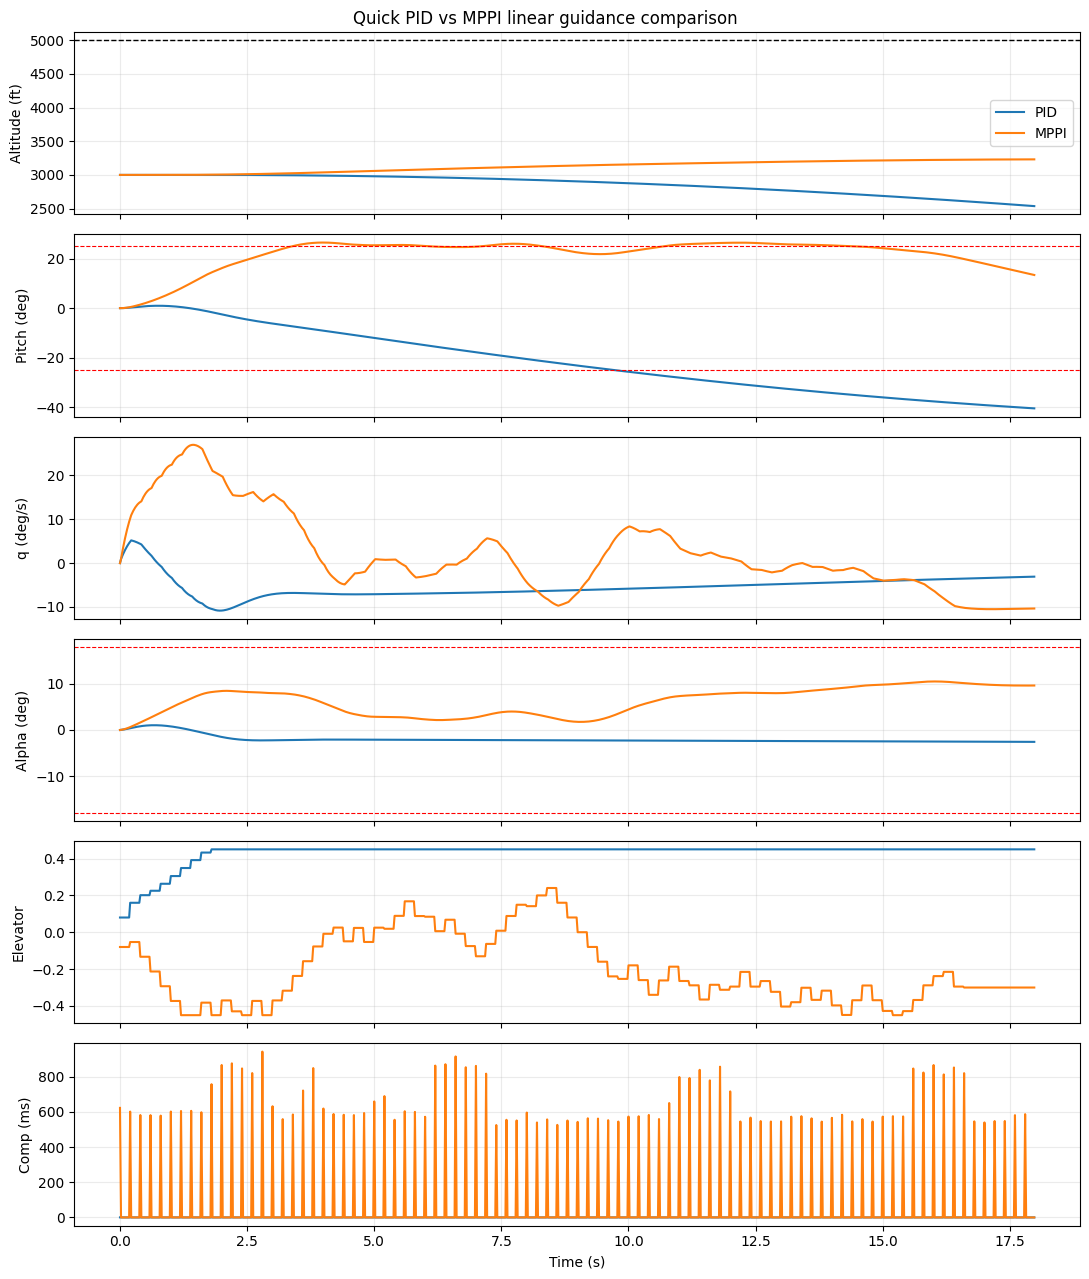

In [12]:
def plot_logs(logs, title='Controller comparison'):
    fig, axes = plt.subplots(6, 1, figsize=(11, 13), sharex=True)
    for log in logs:
        t = np.asarray(log['time'])
        label = log['name']
        axes[0].plot(t, log['altitude'], label=label)
        axes[1].plot(t, log['pitch_deg'], label=label)
        axes[2].plot(t, log['pitch_rate_deg_s'], label=label)
        axes[3].plot(t, log['alpha_deg'], label=label)
        axes[4].plot(t, log['elevator'], label=label)
        axes[5].plot(t, log['comp_ms'], label=label)

    axes[0].axhline(TARGET_ALT, color='k', ls='--', lw=1)
    axes[0].set_ylabel('Altitude (ft)')
    axes[1].axhline(PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[1].axhline(-PITCH_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[1].set_ylabel('Pitch (deg)')
    axes[2].set_ylabel('q (deg/s)')
    axes[3].axhline(ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[3].axhline(-ALPHA_LIMIT_DEG, color='r', ls='--', lw=0.8)
    axes[3].set_ylabel('Alpha (deg)')
    axes[4].set_ylabel('Elevator')
    axes[5].set_ylabel('Comp (ms)')
    axes[5].set_xlabel('Time (s)')
    for ax in axes:
        ax.grid(True, alpha=0.25)
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    return fig


fig = plot_logs(logs, title='Quick PID vs MPPI linear guidance comparison')
fig_path = os.path.join(SAVE_DIR, f'quick_pid_mppi_linear_guidance_comparison_v8_{RUN_MODE}.png')
fig.savefig(fig_path, dpi=160)
print('Saved:', fig_path)
plt.show()


## 10. Optional Full Comparison


In [13]:
def make_test_cases(n_cases=N_TEST_CASES):
    cases = []
    rng = np.random.default_rng(SEED + 100)
    for i in range(n_cases):
        cases.append({
            'case': i,
            'init_alt': float(rng.uniform(2400, 4200)),
            'init_speed': float(rng.uniform(88, 112)),
            'init_pitch': float(rng.uniform(-4, 6)),
            'target_alt': float(rng.uniform(4400, 5600)),
        })
    return cases


all_logs = []
all_metrics = []

if RUN_MODE == 'full':
    cases = make_test_cases()
    for case in cases:
        print('Case:', case)
        for name in SELECTED_CONTROLLERS:
            ctrl = make_controller(name)
            log = run_sim(
                ctrl, name,
                init_alt=case['init_alt'],
                init_speed=case['init_speed'],
                init_pitch=case['init_pitch'],
                target_alt=case['target_alt'],
                max_steps=MAX_STEPS,
                control_interval=CONTROL_INTERVAL,
            )
            m = compute_metrics(log)
            m['Case'] = case['case']
            all_logs.append(log)
            all_metrics.append(m)

multi_metrics = pd.DataFrame(all_metrics)
if len(multi_metrics):
    multi_metrics.to_csv(os.path.join(SAVE_DIR, 'multi_case_metrics_v6_full.csv'), index=False)
multi_metrics


""


## 11. Save Logs


In [14]:
def logs_to_frame(logs):
    rows = []
    for idx, log in enumerate(logs):
        n = len(log['time'])
        for k in range(n):
            rows.append({
                'log_id': idx,
                'controller': log['name'],
                'time': log['time'][k],
                'altitude': log['altitude'][k],
                'velocity': log['velocity'][k],
                'pitch_deg': log['pitch_deg'][k],
                'pitch_rate_deg_s': log['pitch_rate_deg_s'][k],
                'alpha_deg': log['alpha_deg'][k],
                'elevator': log['elevator'][k],
                'theta_cmd_deg': log['theta_cmd_deg'][k],
                'cost': log['cost'][k],
                'comp_ms': log['comp_ms'][k],
                'mpc_update': log['mpc_update'][k],
                'target_alt': log['target_alt'],
                'init_alt': log['init_alt'],
                'control_interval': log['control_interval'],
                'abort_reason': log['abort_reason'] or 'None',
            })
    return pd.DataFrame(rows)


single_log_df = logs_to_frame(logs)
multi_log_df = logs_to_frame(all_logs)
single_log_df.to_csv(os.path.join(SAVE_DIR, f'quick_pid_mppi_linear_guidance_logs_v8_{RUN_MODE}.csv'), index=False)
if len(multi_log_df):
    multi_log_df.to_csv(os.path.join(SAVE_DIR, 'multi_case_logs_v6_full.csv'), index=False)
sanity_df.to_csv(os.path.join(SAVE_DIR, f'cost_sanity_linear_guidance_v8_{RUN_MODE}.csv'), index=False)

config_path = os.path.join(SAVE_DIR, f'pinn_mpc_v6_alpha_linear_guidance_pid_mppi_quick_config_v8_{RUN_MODE}.json')
with open(config_path, 'w') as f:
    json.dump({
        'config': CONFIG,
        'pid_params': PID_PARAMS,
        'model_path': MODEL_PATH,
        'pinn_params': params,
        'pinn_auto_summary': checkpoint.get('auto_summary', {}),
    }, f, indent=2)

run_manifest = {
    'experiment_family': EXPERIMENT_FAMILY,
    'experiment_name': EXPERIMENT_NAME,
    'run_stamp': RUN_STAMP,
    'save_dir': SAVE_DIR,
    'latest_dir': RESULT_LATEST_DIR,
    'run_mode': RUN_MODE,
    'model_path': MODEL_PATH,
    'generated_files': sorted([name for name in os.listdir(SAVE_DIR)]),
}
with open(os.path.join(SAVE_DIR, 'RUN_MANIFEST.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)
with open(os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'), 'w') as f:
    json.dump(run_manifest, f, indent=2)

print('Saved archived results to:', SAVE_DIR)
print('Updated latest run pointer:', os.path.join(RESULT_MODEL_DIR, 'LATEST_RUN.json'))


Saved archived results to: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/archive/20260502_230334
Updated latest run pointer: /content/drive/MyDrive/Colab Result/PINN_MPC/v6_alpha_linear_guidance_PID_MPPI_quick_v8_checkpoint_auto_search/LATEST_RUN.json


## 12. Linear Guidance Quick Compare Guide v8

Use this notebook to test controllers with a simple explicit reference.

Default run:

1. `RUN_MODE = "quick"`
2. Controllers: `PID`, `MPPI` only
3. Initial altitude: `INIT_ALT = 3000 ft`
4. Target altitude: `TARGET_ALT = 5000 ft`
5. Linear reference: 3000 -> 5000 ft over `GUIDANCE_CLIMB_TIME_S = 60 s`
6. Quick settings: `MPC_HORIZON = 100`, `MPC_SAMPLES = 16`, `CONTROL_INTERVAL = 10`, `MAX_STEPS = 900`

What to inspect:

- `sanity_df`: whether the cost prefers a sequence that follows the linear climb reference
- `quick_check`: whether PID and MPPI both climb in JSBSim
- `quick_summary`: Alt RMSE, Final Error, Alt Change, Pitch/Alpha limits, Elevator Smoothness, and computation time

Why this version exists:

- The previous shaped guidance could be too flat over a short horizon.
- This version gives the controller an explicit slope: `(5000 - 3000) / 60 = 33.3 ft/s`.
- The objective is controller testing, not guidance-generation research.

Extension path:

- Add `make_maneuver_guidance(..., maneuver="pitch_doublet")` for elevator/pitch doublet tests.
- Add pull-up, pushover, and pull-up/pull-over references with the same return contract.
- Once PID/MPPI track these references, move to `make_task_guidance()` and then wind/disturbance tests.


Checkpoint loading:

- v8 searches `/content/drive/MyDrive` for compatible `pinn_dynamics_c172_2d*.pt` files.
- It prefers `pinn_dynamics_c172_2d_v6_alpha.pt`, then compatible v7 guidance checkpoints.
- If no checkpoint is found, run the training notebook or copy the checkpoint to `/content/drive/MyDrive/PINN_MODEL_ONLY_v1/`.
